# ASHES Vent Field — Diffuse Hydrothermal Temperature Explorer

**Instrument**: OOI TMPSF sensor (RS03ASHS-MJ03B-07-TMPSFA301) — 24 thermistor channels  
**Location**: ASHES vent field, Axial Seamount (45.93°N, 130.01°W, ~1540 m depth)  
**Data**: QC-filtered hourly temperatures, 2015–2026

This notebook loads pre-processed parquet data and produces matplotlib figures you can download.  
**Change the date range and channels in the Configuration cell below to explore different periods.**

---

## Git Quick Start — Working on Your Own Copy

After cloning this repository, create your own remote so your changes don't affect the original:

```bash
# 1. Clone the repository (you probably already did this)
git clone <original-repo-url> my-tmpsf-analysis
cd my-tmpsf-analysis

# 2. Create your own repository on GitHub (or GitLab, etc.)
#    Go to github.com → New Repository → name it something like "tmpsf-analysis"
#    Do NOT initialize with README (you already have one)

# 3. Point your local copy to YOUR remote instead of the original
git remote rename origin upstream   # keep the original as "upstream" (read-only reference)
git remote add origin <your-repo-url>  # e.g. git@github.com:yourname/tmpsf-analysis.git

# 4. Push to your own repo
git push -u origin master

# 5. Now you can commit and push freely:
git add outputs/notebooks/01_explore_tmpsf.ipynb
git commit -m "My analysis of 2018-2019 TMPSF data"
git push
```

**Key commands you'll use:**

| Command | What it does |
|---------|-------------|
| `git status` | See what files you've changed |
| `git add <file>` | Stage a file for commit |
| `git commit -m "message"` | Save a snapshot of your changes |
| `git push` | Upload your commits to GitHub |
| `git pull upstream master` | Get updates from the original repo |

**Tips:**
- Commit early and often — each time you have a result worth saving
- Write commit messages that describe *what you found*, not just *what you did*
- The `.gitignore` is set up to exclude large data files and images from git — this is intentional
- If you want to save a figure to git, export it as a small PNG or add its path to `.gitignore` exceptions

---

In [19]:
# Environment setup — install required packages into the current kernel
import subprocess, sys, shutil
from pathlib import Path

PACKAGES = ['pandas>=2.0', 'pyarrow>=14.0', 'matplotlib>=3.8',
            'numpy>=1.26', 'xarray>=2024.0', 'netcdf4>=1.6']

if shutil.which('uv'):
    # Fast path: uv is available
    PROJECT_ROOT = Path().resolve().parent.parent
    if (PROJECT_ROOT / 'pyproject.toml').exists():
        subprocess.check_call(['uv', 'add', '--quiet'] + PACKAGES, cwd=PROJECT_ROOT)
        print('Installed via uv add (tracked in pyproject.toml)')
    else:
        subprocess.check_call(['uv', 'pip', 'install', '-q', '--python', sys.executable] + PACKAGES)
        print('Installed via uv pip install')
else:
    # Fallback: standard pip
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + PACKAGES)
    print('Installed via pip')

print('Ready!')

Installed via pip
Ready!


## Configuration

Edit the cell below to change the period of interest and which channels to highlight.

In [20]:
# ======== CHANGE THESE TO EXPLORE DIFFERENT PERIODS ========
START_DATE = '2018-01-01'
END_DATE   = '2019-12-31'

# Data source: 'parquet' (fast, uses pre-built file) or 'netcdf' (builds from raw kdata)
DATA_SOURCE = 'parquet'

# Path to raw NetCDF files (only used if DATA_SOURCE = 'netcdf')
NETCDF_DIR = '/home/jovyan/ooi/kdata/RS03ASHS-MJ03B-07-TMPSFA301-streamed-tmpsf_sample'

# Channels to highlight in the comparison plot (1-24)
# Default: 3 hottest and 3 coolest by long-term mean
HIGHLIGHT_HOT  = [3, 11, 17]   # hottest channels
HIGHLIGHT_COOL = [21, 13, 5]   # coolest channels

# Single channel to examine in detail (Figure 4)
SINGLE_CHANNEL = 7

# Custom set of channels to compare (Figure 5)
CUSTOM_CHANNELS = [1, 5, 7, 8, 14]

# Output directory for saved figures (relative to this notebook)
FIGURE_DIR = '../figures'
# ============================================================

print(f'Data source:     {DATA_SOURCE}')
print(f'Period:          {START_DATE} to {END_DATE}')
print(f'Hot channels:    {HIGHLIGHT_HOT}')
print(f'Cool channels:   {HIGHLIGHT_COOL}')
print(f'Single channel:  Ch{SINGLE_CHANNEL:02d}')
print(f'Custom set:      {["Ch"+str(c).zfill(2) for c in CUSTOM_CHANNELS]}')

Data source:     parquet
Period:          2018-01-01 to 2019-12-31
Hot channels:    [3, 11, 17]
Cool channels:   [21, 13, 5]
Single channel:  Ch07
Custom set:      ['Ch01', 'Ch05', 'Ch07', 'Ch08', 'Ch14']


In [21]:
# Load data — from parquet or raw NetCDF depending on DATA_SOURCE setting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import re
from pathlib import Path

DATA_DIR = Path('../data')
fig_dir = Path(FIGURE_DIR)
fig_dir.mkdir(parents=True, exist_ok=True)

temp_vars = [f'temperature{i:02d}' for i in range(1, 25)]

if DATA_SOURCE == 'parquet':
    # Fast path: load pre-built hourly parquet
    df = pd.read_parquet(DATA_DIR / 'tmpsf_2015-2026_hourly.parquet')
    df = df.loc[START_DATE:END_DATE]
    print(f'Loaded from parquet: {len(df):,} hourly observations')

elif DATA_SOURCE == 'netcdf':
    # Build from raw NetCDF files
    nc_dir = Path(NETCDF_DIR)
    nc_files = sorted(nc_dir.glob('*.nc'))
    start_year = int(START_DATE[:4])
    end_year = int(END_DATE[:4])
    year_range = set(range(start_year, end_year + 1))

    # Filter files by year in filename
    selected = []
    for f in nc_files:
        years_in_name = set(int(y) for y in re.findall(r'20\d{2}', f.name))
        if years_in_name & year_range:
            selected.append(f)

    print(f'Loading {len(selected)} NetCDF files...')
    dfs = []
    for i, f in enumerate(selected):
        ds = xr.open_dataset(f)
        ds = ds.swap_dims({'obs': 'time'})
        avail = [v for v in temp_vars if v in ds.data_vars]
        chunk = ds[avail].sel(time=slice(START_DATE, END_DATE))
        if chunk.sizes['time'] > 0:
            dfs.append(chunk.to_dataframe())
        ds.close()
        if (i + 1) % 10 == 0:
            print(f'  {i+1}/{len(selected)} files loaded')

    df = pd.concat(dfs)
    # Resample to hourly to reduce memory
    df = df.resample('h').mean()
    print(f'Built from NetCDF: {len(df):,} hourly observations')

    # Save parquet for faster future loads
    outpath = DATA_DIR / f'tmpsf_{START_DATE[:4]}-{END_DATE[:4]}_hourly.parquet'
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    df.to_parquet(outpath)
    print(f'Saved parquet for reuse: {outpath}')

temp_cols = [c for c in df.columns if c.startswith('temperature')]
temp_cols.sort()

print(f'Period: {df.index.min()} to {df.index.max()}')
print(f'Channels: {len(temp_cols)}')

Loaded from parquet: 17,520 hourly observations
Period: 2018-01-01 00:00:00 to 2019-12-31 23:00:00
Channels: 24


## Data Overview

Summary statistics for the selected period.

In [22]:
# Per-channel summary statistics
stats = df[temp_cols].describe().T
stats['range'] = stats['max'] - stats['min']
stats = stats[['mean', 'std', 'min', 'max', 'range', 'count']]
stats.index = [c.replace('temperature', 'Ch') for c in stats.index]
print(f'Overall mean: {df[temp_cols].mean().mean():.2f}°C')
print(f'Overall range: {df[temp_cols].min().min():.2f} – {df[temp_cols].max().max():.2f}°C')
print()
stats.round(2)

Overall mean: 3.26°C
Overall range: 2.27 – 13.35°C



,mean,std,min,max,range,count
Ch01,4.03,0.82,2.49,7.82,5.33,16853.0
Ch02,2.64,0.09,2.33,3.35,1.02,16853.0
Ch03,3.04,1.27,2.40,12.41,10.01,16853.0
Ch04,2.86,0.39,2.32,5.15,2.83,16853.0
Ch05,4.09,0.85,2.40,7.65,5.25,16853.0
Ch06,3.24,0.52,2.37,5.20,2.83,16853.0
Ch07,8.13,2.52,2.41,13.35,10.95,15893.0
Ch08,4.21,1.17,2.36,9.59,7.24,16853.0
Ch09,2.89,0.30,2.31,4.55,2.24,16853.0
Ch10,3.34,0.68,2.37,5.56,3.19,16853.0


## Figure 1: All Channels Timeseries

This figure plots all 24 TMPSF thermistor channels as daily-averaged temperature timeseries, color-coded by each channel's long-term mean temperature using the `coolwarm` colormap (blue = cool, red = hot).

**What to look for:**
- Which channels consistently run hotter than others?
- Are there periods where many channels spike simultaneously (possible real hydrothermal events) vs. single-channel spikes (likely sensor artifacts)?
- Are there obvious data gaps (breaks in the lines)?

**How to modify:** Change `START_DATE` and `END_DATE` in the Configuration cell to zoom into a specific period.

Saved: ../figures/tmpsf_all_channels_2018-2019.png


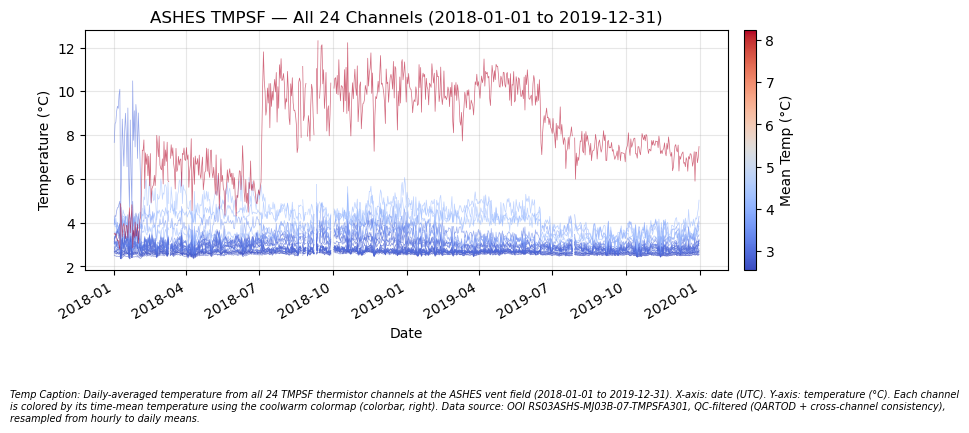

In [23]:
# Resample to daily for cleaner plotting
df_daily = df[temp_cols].resample('D').mean()

# Color channels by their mean temperature
means = df_daily.mean().sort_values()
cmap = plt.cm.coolwarm
norm = plt.Normalize(means.min(), means.max())

fig, ax = plt.subplots(figsize=(10, 4))
for col in means.index:
    ax.plot(df_daily.index, df_daily[col], color=cmap(norm(means[col])),
            alpha=0.6, linewidth=0.5)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, ax=ax, label='Mean Temp (°C)', pad=0.02)

ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.set_title(f'ASHES TMPSF — All 24 Channels ({START_DATE} to {END_DATE})')
ax.grid(alpha=0.3)
fig.autofmt_xdate()

# Temp Caption
cap = (f'Temp Caption: Daily-averaged temperature from all 24 TMPSF thermistor channels '
       f'at the ASHES vent field ({START_DATE} to {END_DATE}). X-axis: date (UTC). '
       f'Y-axis: temperature (°C). Each channel is colored by its time-mean temperature '
       f'using the coolwarm colormap (colorbar, right). Data source: OOI RS03ASHS-MJ03B-07-TMPSFA301, '
       f'QC-filtered (QARTOD + cross-channel consistency), resampled from hourly to daily means.')
fig.text(0.05, -0.02, cap, ha='left', va='top', fontsize=7, style='italic',
         wrap=True, transform=fig.transFigure)
fig.subplots_adjust(bottom=0.28)

outpath = fig_dir / f'tmpsf_all_channels_{START_DATE[:4]}-{END_DATE[:4]}.png'
fig.savefig(outpath, dpi=300, bbox_inches='tight')
print(f'Saved: {outpath}')
plt.show()

## Figure 2: Channel Characterization

This figure shows a bar chart of the time-averaged mean temperature for each of the 24 channels, sorted from hottest to coolest. Error bars show ±1 standard deviation. Channels above the median mean temperature are colored red ("hot"), channels below are blue ("cool"). The dashed gray line marks the median.

**What to look for:**
- Is there a clear bimodal distribution (distinct hot vs. cool groups), or a gradient?
- Which channels have the largest variability (longest error bars)? High variability may indicate proximity to active fluid flow.
- Do any channels have suspiciously low variability (possible sensor issues)?

**How to modify:** Change the date range to see how channel rankings shift over different time periods.

Saved: ../figures/channel_characterization_2018-2019.png


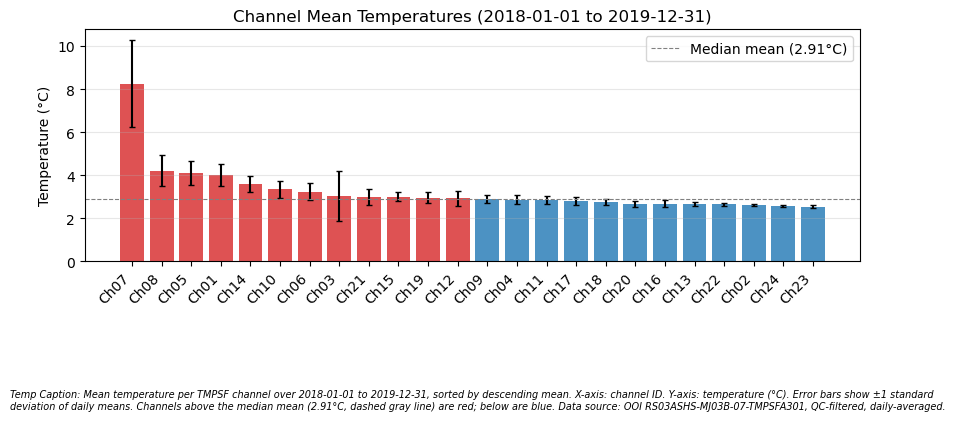

In [24]:
# Channel characterization bar chart
ch_means = df_daily[temp_cols].mean().sort_values(ascending=False)
ch_stds = df_daily[temp_cols].std().reindex(ch_means.index)
median_mean = ch_means.median()

colors = ['#d62728' if m > median_mean else '#1f77b4' for m in ch_means]
labels = [c.replace('temperature', 'Ch') for c in ch_means.index]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(ch_means)), ch_means, yerr=ch_stds, capsize=2,
       color=colors, edgecolor='none', alpha=0.8)
ax.axhline(median_mean, color='gray', linestyle='--', linewidth=0.8,
           label=f'Median mean ({median_mean:.2f}°C)')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylabel('Temperature (°C)')
ax.set_title(f'Channel Mean Temperatures ({START_DATE} to {END_DATE})')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Temp Caption
cap = (f'Temp Caption: Mean temperature per TMPSF channel over {START_DATE} to {END_DATE}, '
       f'sorted by descending mean. X-axis: channel ID. Y-axis: temperature (°C). '
       f'Error bars show ±1 standard deviation of daily means. Channels above the median '
       f'mean ({median_mean:.2f}°C, dashed gray line) are red; below are blue. '
       f'Data source: OOI RS03ASHS-MJ03B-07-TMPSFA301, QC-filtered, daily-averaged.')
fig.text(0.05, -0.02, cap, ha='left', va='top', fontsize=7, style='italic',
         wrap=True, transform=fig.transFigure)
fig.subplots_adjust(bottom=0.30)

outpath = fig_dir / f'channel_characterization_{START_DATE[:4]}-{END_DATE[:4]}.png'
fig.savefig(outpath, dpi=300, bbox_inches='tight')
print(f'Saved: {outpath}')
plt.show()

## Figure 3: Hot vs Cool Channel Comparison

This figure overlays the daily-averaged timeseries for selected "hot" channels (red) and "cool" channels (blue). This direct comparison shows how the temperature contrast between the warmest and coolest thermistors evolves over time.

**What to look for:**
- Do hot and cool channels track each other (correlated variability) or behave independently?
- Are there periods where hot channels cool down to match the cool channels?
- How large is the temperature spread between the two groups?

**How to modify:** Change `HIGHLIGHT_HOT` and `HIGHLIGHT_COOL` in the Configuration cell. Try selecting channels that are adjacent on the sensor array to see if nearby thermistors behave similarly.

Saved: ../figures/hot_vs_cool_2018-2019.png


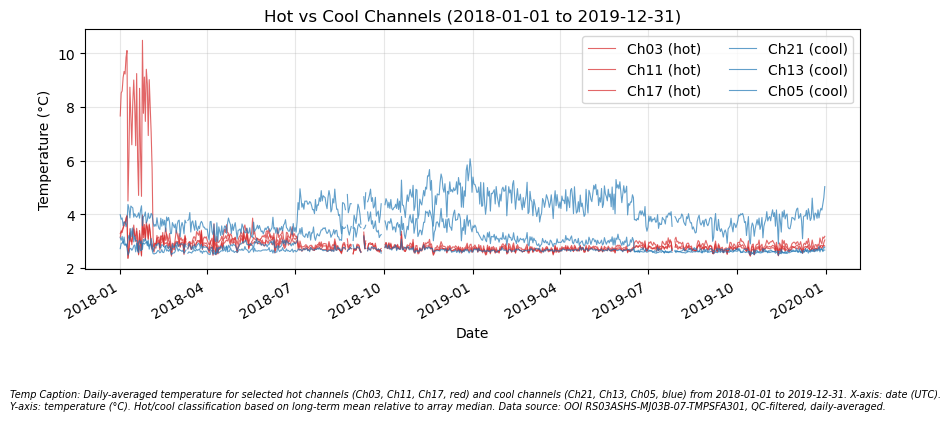

In [25]:
# Hot vs cool channel comparison
fig, ax = plt.subplots(figsize=(10, 4))

hot_labels = []
cool_labels = []
for ch in HIGHLIGHT_HOT:
    col = f'temperature{ch:02d}'
    if col in df_daily.columns:
        ax.plot(df_daily.index, df_daily[col], color='#d62728', alpha=0.7,
                linewidth=0.8, label=f'Ch{ch:02d} (hot)')
        hot_labels.append(f'Ch{ch:02d}')

for ch in HIGHLIGHT_COOL:
    col = f'temperature{ch:02d}'
    if col in df_daily.columns:
        ax.plot(df_daily.index, df_daily[col], color='#1f77b4', alpha=0.7,
                linewidth=0.8, label=f'Ch{ch:02d} (cool)')
        cool_labels.append(f'Ch{ch:02d}')

ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.set_title(f'Hot vs Cool Channels ({START_DATE} to {END_DATE})')
ax.legend(ncol=2)
ax.grid(alpha=0.3)
fig.autofmt_xdate()

# Temp Caption
cap = (f'Temp Caption: Daily-averaged temperature for selected hot channels '
       f'({", ".join(hot_labels)}, red) and cool channels ({", ".join(cool_labels)}, blue) '
       f'from {START_DATE} to {END_DATE}. X-axis: date (UTC). Y-axis: temperature (°C). '
       f'Hot/cool classification based on long-term mean relative to array median. '
       f'Data source: OOI RS03ASHS-MJ03B-07-TMPSFA301, QC-filtered, daily-averaged.')
fig.text(0.05, -0.02, cap, ha='left', va='top', fontsize=7, style='italic',
         wrap=True, transform=fig.transFigure)
fig.subplots_adjust(bottom=0.28)

outpath = fig_dir / f'hot_vs_cool_{START_DATE[:4]}-{END_DATE[:4]}.png'
fig.savefig(outpath, dpi=300, bbox_inches='tight')
print(f'Saved: {outpath}')
plt.show()

## Figure 4: Single Channel Detail

This figure examines one thermistor channel in detail. Gray dots show every hourly data point (revealing the full scatter and any outliers), while the red line traces the daily mean. This lets you see both the high-frequency variability and the longer-term trend.

**What to look for:**
- How much hourly scatter exists around the daily mean? Is it tidal (regular ~12h cycles)?
- Are there abrupt step changes (possible sensor repositioning during maintenance)?
- Do data gaps correspond to known instrument servicing periods?

**How to modify:** Change `SINGLE_CHANNEL` in the Configuration cell. Try channel 7 (hottest, closest to active venting), channel 23 (coolest, likely ambient seawater), or channel 6 (known sensor failure in 2017).

## Summary

Figures saved to the `outputs/figures/` directory. Right-click any figure above to save it, or find the PNG files:

| Figure | File | What to change |
|--------|------|----------------|
| 1. All Channels | `tmpsf_all_channels_YYYY-YYYY.png` | `START_DATE`, `END_DATE` |
| 2. Channel Characterization | `channel_characterization_YYYY-YYYY.png` | `START_DATE`, `END_DATE` |
| 3. Hot vs Cool | `hot_vs_cool_YYYY-YYYY.png` | `HIGHLIGHT_HOT`, `HIGHLIGHT_COOL` |
| 4. Single Channel | `channelNN_detail_YYYY-YYYY.png` | `SINGLE_CHANNEL` |
| 5. Custom Set | `custom_channels_N-N_YYYY-YYYY.png` | `CUSTOM_CHANNELS` |
| 6. Rankings | `channel_rankings_YYYY-YYYY.png` | `START_DATE`, `END_DATE` |

To explore a different time period or channels, go back to the **Configuration** cell, make your changes, and re-run all cells (**Kernel → Restart & Run All**).

Saved: ../figures/channel07_detail_2018-2019.png


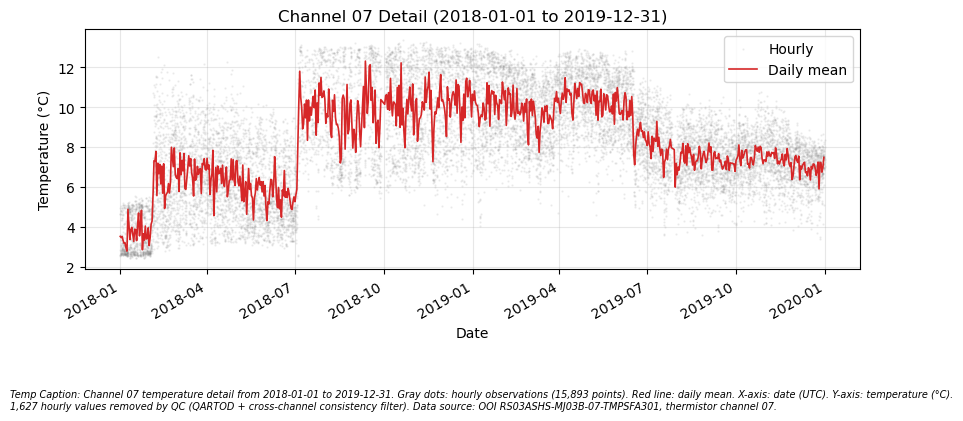

In [8]:
# Single channel detail view
col = f'temperature{SINGLE_CHANNEL:02d}'
ch_hourly = df[col].dropna()
ch_daily = df_daily[col].dropna()

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(ch_hourly.index, ch_hourly.values, s=0.3, alpha=0.15, color='gray', label='Hourly')
ax.plot(ch_daily.index, ch_daily.values, color='#d62728', linewidth=1.2, label='Daily mean')

ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.set_title(f'Channel {SINGLE_CHANNEL:02d} Detail ({START_DATE} to {END_DATE})')
ax.legend()
ax.grid(alpha=0.3)
fig.autofmt_xdate()

# Temp Caption
n_hourly = len(ch_hourly)
n_nan = df[col].isna().sum()
cap = (f'Temp Caption: Channel {SINGLE_CHANNEL:02d} temperature detail from {START_DATE} to {END_DATE}. '
       f'Gray dots: hourly observations ({n_hourly:,} points). Red line: daily mean. '
       f'X-axis: date (UTC). Y-axis: temperature (°C). '
       f'{n_nan:,} hourly values removed by QC (QARTOD + cross-channel consistency filter). '
       f'Data source: OOI RS03ASHS-MJ03B-07-TMPSFA301, thermistor channel {SINGLE_CHANNEL:02d}.')
fig.text(0.05, -0.02, cap, ha='left', va='top', fontsize=7, style='italic',
         wrap=True, transform=fig.transFigure)
fig.subplots_adjust(bottom=0.28)

outpath = fig_dir / f'channel{SINGLE_CHANNEL:02d}_detail_{START_DATE[:4]}-{END_DATE[:4]}.png'
fig.savefig(outpath, dpi=300, bbox_inches='tight')
print(f'Saved: {outpath}')
plt.show()

## Figure 5: Custom Channel Set

This figure plots any user-specified set of channels on the same axes with distinct colors, allowing direct comparison of channels you choose. Use this to test hypotheses about which thermistors might be measuring similar fluid sources.

**What to look for:**
- Do your selected channels covary (rise and fall together), suggesting they sample the same fluid pathway?
- Are there phase lags between channels that might indicate fluid travel time?
- Does adding or removing a channel change your interpretation?

**How to modify:** Change `CUSTOM_CHANNELS` in the Configuration cell to any list of channel numbers (1–24). For example, try `[7, 8, 3]` (the three hottest) or `[1, 2, 3, 4, 5]` (first five sequential channels).

Saved: ../figures/custom_channels_1-5-7-8-14_2018-2019.png


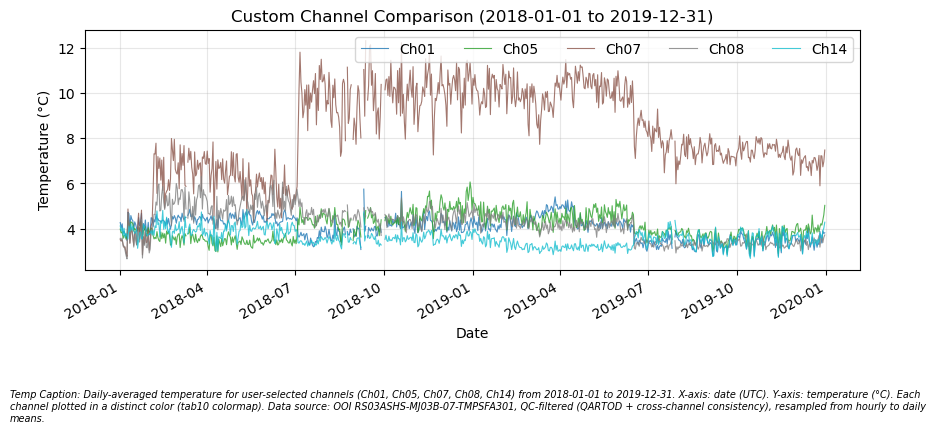

In [9]:
# Custom channel set comparison
colors_custom = plt.cm.tab10(np.linspace(0, 1, len(CUSTOM_CHANNELS)))

fig, ax = plt.subplots(figsize=(10, 4))
ch_labels = []
for ch, color in zip(CUSTOM_CHANNELS, colors_custom):
    col = f'temperature{ch:02d}'
    if col in df_daily.columns:
        ax.plot(df_daily.index, df_daily[col], color=color, linewidth=0.8,
                alpha=0.8, label=f'Ch{ch:02d}')
        ch_labels.append(f'Ch{ch:02d}')

ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.set_title(f'Custom Channel Comparison ({START_DATE} to {END_DATE})')
ax.legend(ncol=min(len(CUSTOM_CHANNELS), 5))
ax.grid(alpha=0.3)
fig.autofmt_xdate()

# Temp Caption
cap = (f'Temp Caption: Daily-averaged temperature for user-selected channels '
       f'({", ".join(ch_labels)}) from {START_DATE} to {END_DATE}. '
       f'X-axis: date (UTC). Y-axis: temperature (°C). Each channel plotted in a distinct '
       f'color (tab10 colormap). Data source: OOI RS03ASHS-MJ03B-07-TMPSFA301, '
       f'QC-filtered (QARTOD + cross-channel consistency), resampled from hourly to daily means.')
fig.text(0.05, -0.02, cap, ha='left', va='top', fontsize=7, style='italic',
         wrap=True, transform=fig.transFigure)
fig.subplots_adjust(bottom=0.28)

ch_str = '-'.join(str(c) for c in CUSTOM_CHANNELS)
outpath = fig_dir / f'custom_channels_{ch_str}_{START_DATE[:4]}-{END_DATE[:4]}.png'
fig.savefig(outpath, dpi=300, bbox_inches='tight')
print(f'Saved: {outpath}')
plt.show()

## Figure 6: Statistical Channel Rankings

Instead of plotting fixed channels, this figure plots whichever channel is the hottest, 2nd hottest, etc. *at each moment in time*. This reveals whether the same thermistor always dominates the temperature ranking, or whether the rankings shift — which would indicate changes in fluid flow pathways.

The plotted lines are:
- **Hottest channel** — the single highest temperature across all 24 channels at each daily timestep
- **2nd hottest** — the second-highest temperature
- **Mean of 3 hottest** — average of the top 3 channels (smooths out single-channel noise)
- **Median channel** — the 12th-ranked channel (a robust measure of "typical" array temperature)
- **Coolest channel** — the single lowest temperature (likely ambient bottom water)

**What to look for:**
- Does the "hottest channel" line stay smooth, or does it jump around? Jumps mean the identity of the hottest channel is changing.
- How wide is the spread between hottest and coolest? Does it narrow or widen over time?
- Does the median track the coolest channel (most channels see ambient water) or something warmer?

**How to modify:** Change the date range to focus on periods of interest. Try zooming into the April 2015 eruption (`START_DATE = '2015-04-01'`, `END_DATE = '2015-07-01'`) to see how the rankings responded.

Saved: ../figures/channel_rankings_2018-2019.png


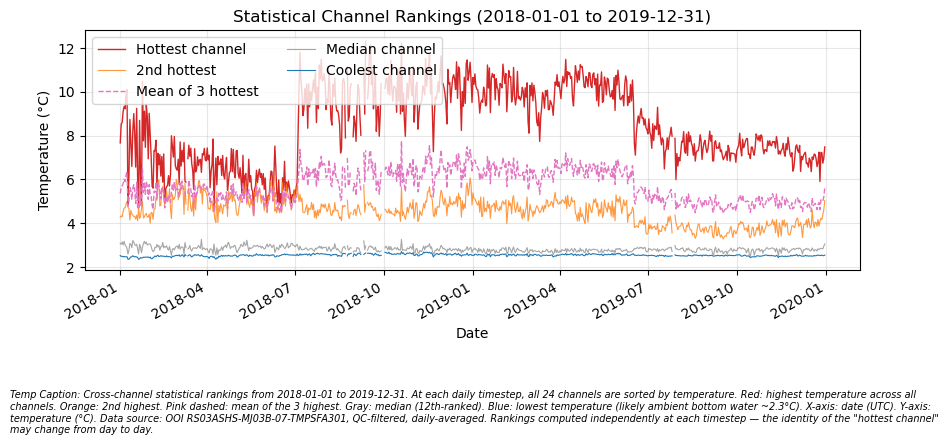

In [10]:
# Statistical rankings — at each timestep, rank all 24 channels by temperature
daily_temps = df_daily[temp_cols]

# Sort across channels at each timestep (axis=1), then pick by rank
ranked = pd.DataFrame(
    np.sort(daily_temps.values, axis=1),
    index=daily_temps.index,
    columns=[f'rank_{i+1}' for i in range(len(temp_cols))]
)

fig, ax = plt.subplots(figsize=(10, 4))

# Hottest at each moment
ax.plot(ranked.index, ranked['rank_24'], color='#d62728', linewidth=1,
        label='Hottest channel')
ax.plot(ranked.index, ranked['rank_23'], color='#ff7f0e', linewidth=0.8,
        alpha=0.8, label='2nd hottest')

# Mean of top 3
top3_mean = ranked[['rank_24', 'rank_23', 'rank_22']].mean(axis=1)
ax.plot(ranked.index, top3_mean, color='#e377c2', linewidth=1,
        linestyle='--', label='Mean of 3 hottest')

# Median of all channels
ax.plot(ranked.index, ranked['rank_12'], color='gray', linewidth=0.8,
        alpha=0.7, label='Median channel')

# Coolest
ax.plot(ranked.index, ranked['rank_1'], color='#1f77b4', linewidth=0.8,
        label='Coolest channel')

ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.set_title(f'Statistical Channel Rankings ({START_DATE} to {END_DATE})')
ax.legend(ncol=2)
ax.grid(alpha=0.3)
fig.autofmt_xdate()

# Temp Caption
cap = (f'Temp Caption: Cross-channel statistical rankings from {START_DATE} to {END_DATE}. '
       f'At each daily timestep, all 24 channels are sorted by temperature. '
       f'Red: highest temperature across all channels. Orange: 2nd highest. '
       f'Pink dashed: mean of the 3 highest. Gray: median (12th-ranked). '
       f'Blue: lowest temperature (likely ambient bottom water ~2.3°C). '
       f'X-axis: date (UTC). Y-axis: temperature (°C). '
       f'Data source: OOI RS03ASHS-MJ03B-07-TMPSFA301, QC-filtered, daily-averaged. '
       f'Rankings computed independently at each timestep — the identity of the '
       f'"hottest channel" may change from day to day.')
fig.text(0.05, -0.02, cap, ha='left', va='top', fontsize=7, style='italic',
         wrap=True, transform=fig.transFigure)
fig.subplots_adjust(bottom=0.28)

outpath = fig_dir / f'channel_rankings_{START_DATE[:4]}-{END_DATE[:4]}.png'
fig.savefig(outpath, dpi=300, bbox_inches='tight')
print(f'Saved: {outpath}')
plt.show()